In [1]:
# standard libraries
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.append('..')

In [2]:
beta = 0.5
cpi = 2

## Exact PDE solution

t=0.000, alpha=0.999970
t=0.100, alpha=0.874102
t=0.200, alpha=0.785843
t=0.300, alpha=0.721697
t=0.400, alpha=0.673850
t=0.500, alpha=0.637461
t=0.600, alpha=0.609376
t=0.700, alpha=0.587453
t=0.800, alpha=0.570188
t=0.900, alpha=0.556497
t=1.000, alpha=0.545580
t=1.100, alpha=0.536839
t=1.200, alpha=0.529814
t=1.300, alpha=0.524155
t=1.400, alpha=0.519585
t=1.500, alpha=0.515890
t=1.600, alpha=0.512897
t=1.700, alpha=0.510470
t=1.800, alpha=0.508502
t=1.900, alpha=0.506904
t=2.000, alpha=0.505607
t=2.100, alpha=0.504553
t=2.200, alpha=0.503697
t=2.300, alpha=0.503001
t=2.400, alpha=0.502436
t=2.500, alpha=0.501977
t=2.600, alpha=0.501604
t=2.700, alpha=0.501301
t=2.800, alpha=0.501055
t=2.900, alpha=0.500855
t=3.000, alpha=0.500693
t=3.100, alpha=0.500562
t=3.200, alpha=0.500457
t=3.300, alpha=0.500372
t=3.400, alpha=0.500303
t=3.500, alpha=0.500248
t=3.600, alpha=0.500203
t=3.700, alpha=0.500168
t=3.800, alpha=0.500139
t=3.900, alpha=0.500116
t=4.000, alpha=0.500097
t=4.100, alpha=0

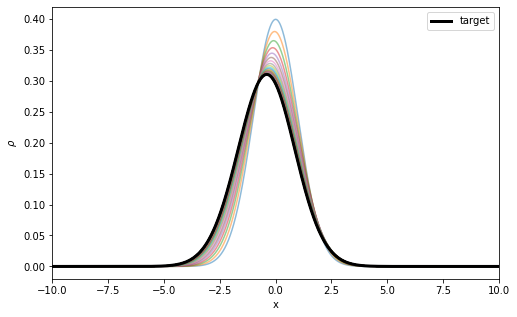

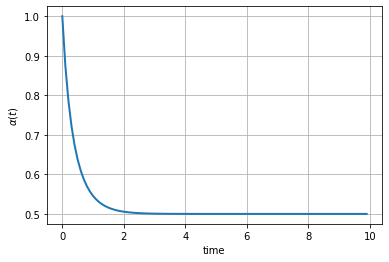

In [3]:
# ==========================================================
# Parameters
# ==========================================================

xmin = -20.0
xmax = 15.0
Nx = 5000

x = np.linspace(xmin, xmax, Nx)
dx = x[1] - x[0]

T = 10.0
dt = 2e-5
Nt = int(T / dt)

save_every = 5000

# ==========================================================
# Initial density
# ==========================================================

var0 = 1.0

rho0 = np.exp(-x**2/(2*var0))
rho0 /= np.trapz(rho0, x)

u = np.log(rho0)

# ==========================================================
# Target density
# pi(x) ∝ exp(-x²/4 - 0.5 log(1+exp(x)))
# ==========================================================

log_pi = -(x**2)/4 - 0.5*np.log1p(np.exp(x))

sig = 1.0/(1.0 + np.exp(-x))

dlog_pi = -(x/2 + 0.5*sig)

d2log_pi = -(0.5 + 0.5*sig*(1.0-sig))

pi = np.exp(log_pi)
pi /= np.trapz(pi, x)

# ==========================================================
# Region used for log-concavity
# ==========================================================

mask = (x > -15) & (x < 10)

history = []
alphas = []
times = []

# ==========================================================
# Time loop
# ==========================================================

for n in range(Nt):

    # Recover normalized density
    rho = np.exp(u)
    rho /= np.trapz(rho, x)

    # First derivative
    ux = np.gradient(u, dx, edge_order=2)

    # Second derivative
    uxx = np.gradient(ux, dx, edge_order=2)

    # Relative entropy expectation
    mean = np.trapz(rho * (u - log_pi), x)

    # RHS of log-density PDE
    rhs = (
        uxx
        + ux**2
        - ux*dlog_pi
        - d2log_pi
        - u
        + log_pi
        + mean
    )

    # Euler step
    u += dt * rhs

    # Diagnostics
    if n % save_every == 0:

        rho = np.exp(u)
        rho /= np.trapz(rho, x)

        history.append(rho.copy())
        times.append((n+1)*dt)

        ux = np.gradient(u, dx, edge_order=2)
        uxx = np.gradient(ux, dx, edge_order=2)

        alpha = -np.max(uxx[mask])

        alphas.append(alpha)

        print(
            f"t={(n+1)*dt:.3f}, "
            f"alpha={alpha:.6f}"
        )

# ==========================================================
# Plot density
# ==========================================================

plt.figure(figsize=(8,5))

for sol in history:
    plt.plot(x, sol, alpha=0.5)

plt.plot(x, pi, 'k', lw=3, label='target')

plt.xlim([-10,10])
plt.xlabel("x")
plt.ylabel(r"$\rho$")
plt.legend()

# ==========================================================
# Plot log-concavity constant
# ==========================================================

plt.figure(figsize=(6,4))

plt.plot(times, alphas, lw=2)

plt.xlabel("time")
plt.ylabel(r"$\alpha(t)$")

plt.grid(True)

plt.show()

## Log-concavity constant

In [4]:
## evolution from Theorem 4.1
alphapi = 1/cpi
Lpi = 1/cpi + beta/4

sigma0 = 1

delta = 0.5
alphad = 1/sigma0 - (1+delta)/(2*cpi) - (1+delta)*beta/8

alphah = -beta/8 + 1/(2*cpi**2)-beta/(2*np.e*cpi)-beta**2/4+1/cpi
b = np.sqrt(0.5*np.abs(alphah-Lpi))

if alphah - Lpi < 0:
    r = alphapi/2 - 2*b**2
else:
    r = alphapi/2 + 2*b**2

m = np.sqrt(0.5*(1/8+r))

c0_theorem = alphad + delta*alphapi/2

In [5]:
discr = 1000
gamma = 0.01

alpha_eq_theo = np.zeros(discr+1)
t = 0
alpha_eq_theo[0] = (alphapi/2
    - 1/4
    + m * (
        (m + c0_theorem + 1/4)
        - (m - c0_theorem - 1/4)*np.exp(-4*m*t)
    ) / (
        (m + c0_theorem + 1/4)
        + (m - c0_theorem - 1/4)*np.exp(-4*m*t)
    )
                   )
for i in range(discr):
    t = gamma*(i+1)
    alpha_eq_theo[i+1] = (
        alphapi/2
        - 1/4
        + m * (
            (m + c0_theorem + 1/4)
            - (m - c0_theorem - 1/4)*np.exp(-4*m*t)
        ) / (
            (m + c0_theorem + 1/4)
            + (m - c0_theorem - 1/4)*np.exp(-4*m*t)
        )
    )

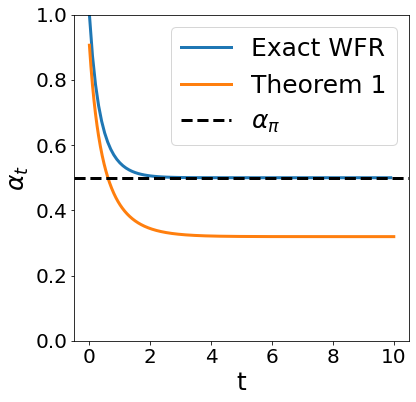

In [6]:
plt.figure(figsize = (6, 6))
plt.plot(times, alphas, label = 'Exact WFR', lw = 3)
plt.plot(gamma*np.arange(discr+1), alpha_eq_theo, label = 'Theorem 1', lw = 3)
plt.axhline(y=alphapi, color='black', linestyle='--', label = r'$\alpha_\pi$', lw = 3)
plt.legend(fontsize = 25)
plt.xlabel('t', fontsize = 25)
plt.ylabel(r'$\alpha_t$', fontsize = 25)
plt.xticks(fontsize = 20);
plt.yticks(fontsize = 20);
plt.ylim(0, 1);
# plt.savefig('Sec4_logconc_nongauss_pi_bet05cpi2.pdf', bbox_inches="tight")

In [7]:
alpha_eq_theo[-1], alphapi/2-1/4+m

(0.31938705001959505, 0.3193861846210397)

## Symmetrised KL Decay

In [8]:
def symmetrised_kl(x, mu, pi, eps=1e-300):
    mu = np.maximum(np.asarray(mu), eps)
    pi = np.maximum(np.asarray(pi), eps)

    integrand = (mu - pi) * np.log(mu / pi)

    return np.trapz(integrand, x)

In [9]:
j_theo = np.zeros(Nt)
j_theo[0] = symmetrised_kl(x, history[0], pi)
for i in range(1, Nt):
    t = dt*i
    j_theo[i] = j_theo[0]*np.exp(-t*(1+alphapi))

In [10]:
## exact WFR decay
j_exact = np.zeros(len(history))
for i in range(len(history)):
    j_exact[i] = symmetrised_kl(x, history[i], pi)

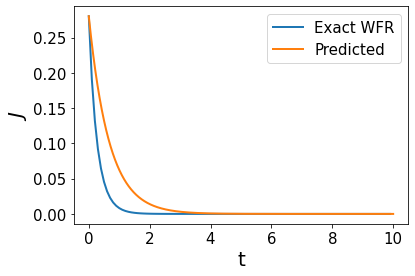

In [11]:
plt.plot(dt*np.arange(Nt+1, step = save_every), j_exact, label = 'Exact WFR', lw = 2)
plt.plot(dt*np.arange(Nt), j_theo, label = 'Predicted', lw = 2)
plt.legend(fontsize = 15)
plt.xlabel('t', fontsize = 20)
plt.ylabel(r'$J$', fontsize = 20)
plt.xticks(fontsize = 15);
plt.yticks(fontsize = 15);
# plt.savefig('j_rate_jmlr_logconc_nongauss.pdf', bbox_inches="tight")